# TelecomX LATAM – Limpieza de Datos y Analisis Churn



*   Extracción de datos
*   Normalización de JSON
*   Limpieza de columnas
*   Transformación de variables
*   características
*   EDA básico
*   Matriz de correlación






In [110]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas import json_normalize

## 1. Extracion de Datos

In [111]:
url = "https://raw.githubusercontent.com/gonzalezgodoywilliam-pixel/CHALLENGE_2_-ALURA_LATAM/main/TelecomX_Data.json"

response = requests.get(url)
response.raise_for_status()

data_json = response.json()

df = json_normalize(data_json)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## 2. Limpieza de columnas

In [112]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace(".", "_", regex=False)
)

df.columns

Index(['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'internet_techsupport',
       'internet_streamingtv', 'internet_streamingmovies', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total'],
      dtype='object')

## 3. Limpieza de Textos



In [113]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip().str.lower()

df.head()

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
0,0002-orfbo,no,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.3
1,0003-mknfe,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.4
2,0004-tlhlj,yes,male,0,no,no,4,yes,no,fiber optic,...,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85
3,0011-igkff,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85
4,0013-exchz,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.4


## 4. Convertir Variables Binarias

In [114]:
binary_map = {
    'yes': 1,
    'no': 0,
    'no internet service': 0,
    'no phone service': 0
}

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].replace(binary_map)

/tmp/ipykernel_432/866888195.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(binary_map)


## 5. Convertir Datos Numericos

In [115]:
if 'account_charges_total' in df.columns:
    df['account_charges_total'] = pd.to_numeric(df['account_charges_total'], errors='coerce')

## 6. Carateristicas

In [116]:
if 'account_charges_monthly' in df.columns:
    df['daily_charges'] = df['account_charges_monthly'] / 30

## 7. Distribución Churn

In [117]:
if 'churn' in df.columns:
    churn_counts = df['churn'].value_counts(dropna=False)
    churn_counts

## 8. Churn

Churn rate: 26.54%


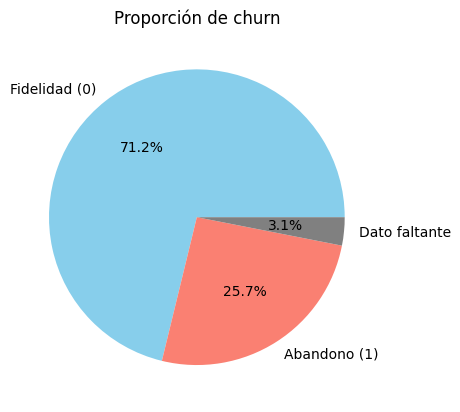

In [118]:
if 'churn' in df.columns:

    df['churn'] = pd.to_numeric(df['churn'], errors='coerce')

    churn_rate = df['churn'].mean() * 100
    print(f"Churn rate: {churn_rate:.2f}%")

import matplotlib.pyplot as plt
import pandas as pd

# Conteo de churn incluyendo NaN
churn_counts = df['churn'].value_counts(dropna=False)

# Reemplazar índices por etiquetas descriptivas
new_index = []
for val in churn_counts.index:
    if pd.isna(val):
        new_index.append('Dato faltante')
    elif val == 0:
        new_index.append('Fidelidad (0)')
    elif val == 1:
        new_index.append('Abandono (1)')
    else:
        new_index.append(val)

churn_counts.index = new_index

# Gráfico de pastel
churn_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','salmon','gray']
)
plt.title('Proporción de churn')
plt.ylabel('')
plt.show()

## 9. Correlacion Matrix

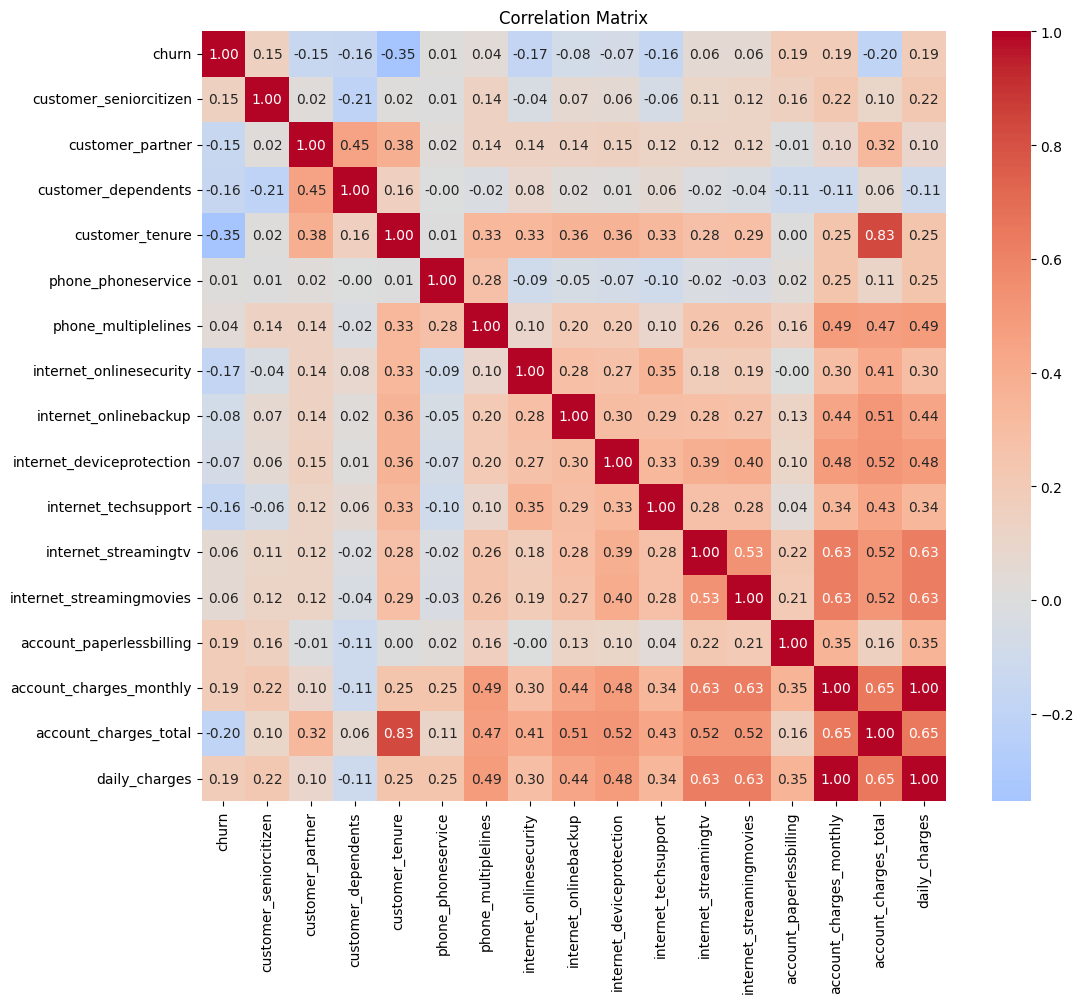

In [119]:
df_numeric = df.select_dtypes(include=[np.number])

corr_matrix = df_numeric.dropna().corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Correlation Matrix')
plt.show()